# P1a · Rural Population Recovery in Spain (1996–2024)
## *Net Padrón Change by Municipality Size and Goerlich (2016) Typology*

---

**Paper:** Rural Migration and Land Use in Spain — Paper 1  
**Step:** 1a — Net padrón change analysis (Part A of three)  
**Author:** Juan Zotes  
**Last updated:** 2026-03-24

---

### Context and purpose

The MITERD grey report (2022) claims that small municipalities (<5,000 inhabitants)
reversed their residential balance around **2018**, based on the *Estadística de
Variaciones Residenciales* (EVR). This notebook provides an independent empirical
verification of that date using municipal-level population data from the
*Padrón Municipal* (1996–2024).

This is **Part A** of a three-notebook series:

| Notebook | Outcome variable | Source |
|----------|-----------------|--------|
| **p1a** (this notebook) | Net padrón change (ΔP) | Padrón Municipal 1996–2024 |
| p1b | Estimated migratory balance (ΔP − vegetative balance) | Padrón + MNP 1998–2024 |
| p1c | Comparison of p1a and p1b results | — |

### Outcome variable

**Annual net population change** at the municipal level:

$$\Delta P_{i,t} = P_{i,t} - P_{i,t-1}$$

This measure integrates both migratory and vegetative components. It differs
from the residential balance (EVR) used by MITERD (2022), which captures
migratory flows only. EVR microdata are not publicly available at municipal
scale for municipalities below 10,000 inhabitants (INE confidentiality policy).
The ~2-year lag between the MITERD inflection (2018) and the sustained positive
net padrón change observed here (~2020) is consistent with the structural
negative vegetative balance of small rural municipalities, and is quantified
in p1b.

### Size classification reference year

Municipality size groups are assigned using **2020 population** as the reference
year. See methodology note in the paper for full justification.

### Output figures

| Figure | Content | Groups |
|--------|---------|--------|
| Fig. 1 | National aggregate | All municipalities, 1999–2024 |
| Fig. 2 | By size group | > 50,000 / 10,000–50,000 / 5,000–10,000 / <5,000 (total) / 1,000–5,000 / <1,000 |
| Fig. 3 | By Goerlich (2016) typology | 6 functional categories |

Each figure is saved in EN and ES, and in three formats: combined (3×2), pairs, and individual panels.  
All files saved to `figures/p1a_padron/`.

### Inputs

| File | Location | Description |
|------|----------|-------------|
| `01_padron_clean_1996_2024.csv` | `data/demography/processed/` | Municipal population 1996–2024, long format |
| `p0_municipios_goerlich_admin_hierarchy.csv` | `data/spatial/processed/` | Municipal typology + administrative hierarchy |

In [1]:
"""
Notebook  : p1a_rural_population_recovery_padron.ipynb
Author    : Juan Zotes
Created   : 2026-03-24

Purpose:
    Analyse annual net population change (Padrón Municipal, 1996–2024) for
    Spanish municipalities, stratified by size group and Goerlich (2016)
    functional typology. Provides independent empirical verification of the
    2018 demographic inflection point reported by MITERD (2022) using net
    padrón change as the outcome variable.

    This is Part A of a three-notebook series:
        p1a — Net padrón change (this notebook)
        p1b — Estimated migratory balance (padrón minus vegetative balance
              from MNP, 1998–2024)
        p1c — Comparison of p1a and p1b results

Inputs:
    - 01_padron_clean_1996_2024.csv              (demography/processed)
    - p0_municipios_goerlich_admin_hierarchy.csv (spatial/processed)

Outputs:
    Figures (figures/p1a_padron/):
        - p1_fig1_national_net_change_{lang}.png
        - p1_fig2_size_combined_{lang}.png
        - p1_fig2_size_pair_{top/mid/bot}_{lang}.png
        - p1_fig2_size_individual_{group}_{lang}.png
        - p1_fig3_typology_combined_{lang}.png
        - p1_fig3_typology_pair_{top/mid/bot}_{lang}.png
        - p1_fig3_typology_individual_{type}_{lang}.png

    Derived data (demography/derived/):
        - p1_annual_net_change_national.csv
        - p1_annual_net_change_by_size.csv
        - p1_annual_net_change_by_typology.csv
        - p1_inflection_summary.csv

Notes:
    - Outcome variable: net padrón change (ΔP = P_t − P_{t-1}), which
      integrates both migratory and vegetative components. This differs
      from the residential balance (EVR) used by MITERD (2022), which
      captures migratory flows only. EVR microdata are not publicly
      available at municipal scale for municipalities <10,000 inhabitants
      (INE confidentiality policy).
    - Municipality size classification based on 2020 population (reference
      year). See methodology note in paper for full justification.
    - The ~2-year lag between the MITERD inflection (2018) and the
      sustained positive net padrón change observed here (~2020) is
      consistent with the structural negative vegetative balance of small
      rural municipalities. This is quantified in p1b.
"""

'\nNotebook  : p1a_rural_population_recovery_padron.ipynb\nAuthor    : Juan Zotes\nCreated   : 2026-03-24\n\nPurpose:\n    Analyse annual net population change (Padrón Municipal, 1996–2024) for\n    Spanish municipalities, stratified by size group and Goerlich (2016)\n    functional typology. Provides independent empirical verification of the\n    2018 demographic inflection point reported by MITERD (2022) using net\n    padrón change as the outcome variable.\n\n    This is Part A of a three-notebook series:\n        p1a — Net padrón change (this notebook)\n        p1b — Estimated migratory balance (padrón minus vegetative balance\n              from MNP, 1998–2024)\n        p1c — Comparison of p1a and p1b results\n\nInputs:\n    - 01_padron_clean_1996_2024.csv              (demography/processed)\n    - p0_municipios_goerlich_admin_hierarchy.csv (spatial/processed)\n\nOutputs:\n    Figures (figures/p1a_padron/):\n        - p1_fig1_national_net_change_{lang}.png\n        - p1_fig2_size_

---
## 0 · Environment and paths

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

print("Libraries loaded.")

Libraries loaded.


In [3]:
# --- Paths -----------------------------------------------------------
BASE_DIR = Path(
    r"C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE"
    r"\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain"
)

DEMO_PROC    = BASE_DIR / "data" / "demography" / "processed"
DEMO_DERIV   = BASE_DIR / "data" / "demography" / "derived"
SPATIAL_PROC = BASE_DIR / "data" / "spatial" / "processed"
FIGURES_DIR = BASE_DIR / "figures" / "p1a_padron"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FP_PADRON   = DEMO_PROC   / "01_padron_clean_1996_2024.csv"
FP_GOERLICH = SPATIAL_PROC / "p0_municipios_goerlich_admin_hierarchy.csv"

print("Paths defined.")
for p in [FP_PADRON, FP_GOERLICH]:
    print(f"  {'OK' if p.exists() else 'MISSING'} → {p.name}")

Paths defined.
  OK → 01_padron_clean_1996_2024.csv
  OK → p0_municipios_goerlich_admin_hierarchy.csv


In [4]:
# --- Colour palettes -------------------------------------------------

# Goerlich typology (consistent with QGIS symbology)
GOERLICH_COLORS = {
    "Rural - Accesible"    : "#74c476",
    "Rural - Remoto"       : "#238b45",
    "Intermedio - Abierto" : "#6baed6",
    "Intermedio - Cerrado" : "#2171b5",
    "Urbano - Abierto"     : "#fd8d3c",
    "Urbano - Cerrado"     : "#bd0026",
}

TYPOLOGY_ORDER = [
    "Urbano - Cerrado",
    "Urbano - Abierto",
    "Intermedio - Cerrado",
    "Intermedio - Abierto",
    "Rural - Accesible",
    "Rural - Remoto",
]

# Size groups — ordered largest to smallest
SIZE_ORDER = [
    "> 50,000",
    "10,000 – 50,000",
    "5,000 – 10,000",
    "< 5,000 (total)",
    "1,000 – 5,000",
    "< 1,000",
]

SIZE_COLORS = {
    "> 50,000"        : "#bd0026",
    "10,000 – 50,000" : "#fd8d3c",
    "5,000 – 10,000"  : "#fecc5c",
    "< 5,000 (total)" : "#2171b5",
    "1,000 – 5,000"   : "#6baed6",
    "< 1,000"         : "#238b45",
}

# Shared bar colours: blue = gain, red = loss
COL_POS = "#2171b5"
COL_NEG = "#c0392b"

print("Palettes defined.")

Palettes defined.


---
## 1 · Load and prepare data

In [5]:
# --- Load padrón (Total rows only) -----------------------------------
padron = pd.read_csv(FP_PADRON, dtype={"Mun_Code": str}, encoding="UTF-8")
padron["Mun_Code"] = padron["Mun_Code"].str.zfill(5)
padron_total = padron[padron["Cat"] == "Total"].copy()

print(f"Padrón loaded  : {len(padron_total):,} rows")
print(f"Municipalities : {padron_total['Mun_Code'].nunique():,}")
print(f"Years          : {sorted(padron_total['Year'].unique())}")

Padrón loaded  : 227,696 rows
Municipalities : 8,132
Years          : [np.int64(1996), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [6]:
# --- Load Goerlich typology ------------------------------------------
goerlich = pd.read_csv(
    FP_GOERLICH, dtype={"Mun_Code": str}, sep=";", encoding="utf-8-sig"
)
goerlich["Mun_Code"] = goerlich["Mun_Code"].str.zfill(5)

print(f"Goerlich loaded: {len(goerlich):,} rows")
print(goerlich["tipo_goerlich"].value_counts())

Goerlich loaded: 8,132 rows
tipo_goerlich
Rural - Accesible       3885
Rural - Remoto          2838
Intermedio - Abierto     972
Intermedio - Cerrado     190
Urbano - Cerrado         164
Urbano - Abierto          83
Name: count, dtype: int64


In [7]:
# --- Assign size group using 2020 population (reference year) --------
REF_YEAR = 2020

pop_ref = (
    padron_total[padron_total["Year"] == REF_YEAR][["Mun_Code", "Pop"]]
    .rename(columns={"Pop": "Pop_ref"})
)

def assign_size_group(pop):
    if   pop <  1_000:  return "< 1,000"
    elif pop <  5_000:  return "1,000 – 5,000"
    elif pop < 10_000:  return "5,000 – 10,000"
    elif pop < 50_000:  return "10,000 – 50,000"
    else:               return "> 50,000"

pop_ref["size_group"] = pop_ref["Pop_ref"].apply(assign_size_group)

print(f"Size group distribution (ref. {REF_YEAR}):")
print(pop_ref["size_group"].value_counts())

Size group distribution (ref. 2020):
size_group
< 1,000            5004
1,000 – 5,000      1823
10,000 – 50,000     610
5,000 – 10,000      545
> 50,000            150
Name: count, dtype: int64


In [8]:
# --- Merge all metadata into padrón ----------------------------------
df = padron_total.merge(pop_ref[["Mun_Code", "Pop_ref", "size_group"]],
                        on="Mun_Code", how="left")
df = df.merge(goerlich[["Mun_Code", "tipo_goerlich"]],
              on="Mun_Code", how="left")

print(f"Merged rows    : {len(df):,}")
print(f"Missing size   : {df['size_group'].isna().sum()}")
print(f"Missing typol. : {df['tipo_goerlich'].isna().sum()}")

Merged rows    : 227,696
Missing size   : 0
Missing typol. : 0


---
## 2 · Compute annual net population change

$$\Delta P_{i,t} = P_{i,t} - P_{i,t-1}$$

Non-annual gaps (e.g. the 1996→1998 jump in the historical padrón) are set to NaN
to avoid spurious two-year differences entering the annual aggregates.

In [9]:
df = df.sort_values(["Mun_Code", "Year"]).reset_index(drop=True)

df["Pop_prev"]  = df.groupby("Mun_Code")["Pop"].shift(1)
df["Year_prev"] = df.groupby("Mun_Code")["Year"].shift(1)
df["Year_gap"]  = df["Year"] - df["Year_prev"]
df["Net_change"] = df["Pop"] - df["Pop_prev"]

# Nullify non-annual transitions
df.loc[df["Year_gap"] != 1, "Net_change"] = np.nan
df = df.drop(columns=["Pop_prev", "Year_prev", "Year_gap"])

print(f"Net change computed.")
print(f"NaN rows (gaps or first year): {df['Net_change'].isna().sum():,}")

Net change computed.
NaN rows (gaps or first year): 16,715


---
## 3 · Aggregate series

We build four aggregated datasets:
- **National** — all municipalities
- **By size group** — five groups + <5,000 aggregate
- **By Goerlich typology** — six categories

In [10]:
# --- Helper: clean aggregate -----------------------------------------
def agg_net(frame, group_col=None):
    """Aggregate Net_change by Year (and optionally by group_col)."""
    if group_col:
        return (
            frame.groupby(["Year", group_col])["Net_change"]
            .sum(min_count=1).reset_index()
            .dropna(subset=["Net_change"])
        )
    return (
        frame.groupby("Year")["Net_change"]
        .sum(min_count=1).reset_index()
        .dropna(subset=["Net_change"])
    )


# National
national = agg_net(df)
national.columns = ["Year", "Net_change"]
print(f"National series : {len(national)} years")

# By size group (five standard groups)
by_size = agg_net(df.dropna(subset=["size_group"]), group_col="size_group")

# < 5,000 aggregate (combines < 1,000 and 1,000–5,000)
df_small = df[df["Pop_ref"] < 5000].copy()
small_agg = agg_net(df_small)
small_agg["size_group"] = "< 5,000 (total)"
small_agg = small_agg.rename(columns={"Net_change": "Net_change"})

# Concatenate size series
by_size_full = pd.concat(
    [by_size, small_agg[["Year", "Net_change", "size_group"]]],
    ignore_index=True
)

# By Goerlich typology
by_typology = agg_net(df.dropna(subset=["tipo_goerlich"]), group_col="tipo_goerlich")

print(f"Size groups     : {by_size_full['size_group'].unique()}")
print(f"Typology groups : {by_typology['tipo_goerlich'].unique()}")

National series : 26 years
Size groups     : ['1,000 – 5,000' '10,000 – 50,000' '5,000 – 10,000' '< 1,000' '> 50,000'
 '< 5,000 (total)']
Typology groups : ['Intermedio - Abierto' 'Intermedio - Cerrado' 'Rural - Accesible'
 'Rural - Remoto' 'Urbano - Abierto' 'Urbano - Cerrado']


In [11]:
# --- Save derived CSVs -----------------------------------------------
national.to_csv(DEMO_DERIV / "p1_annual_net_change_national.csv",
                index=False, sep=";", encoding="utf-8-sig")
by_size_full.to_csv(DEMO_DERIV / "p1_annual_net_change_by_size.csv",
                    index=False, sep=";", encoding="utf-8-sig")
by_typology.to_csv(DEMO_DERIV / "p1_annual_net_change_by_typology.csv",
                   index=False, sep=";", encoding="utf-8-sig")

print("All derived CSVs saved to data/demography/derived/")

All derived CSVs saved to data/demography/derived/


---
## 4 · Figure 1 — National aggregate (1997–2024)

Bar chart of annual net population change for all Spanish municipalities.
Blue bars = net gain; grey bars = net loss. Vertical dashed line marks the
inflection year.

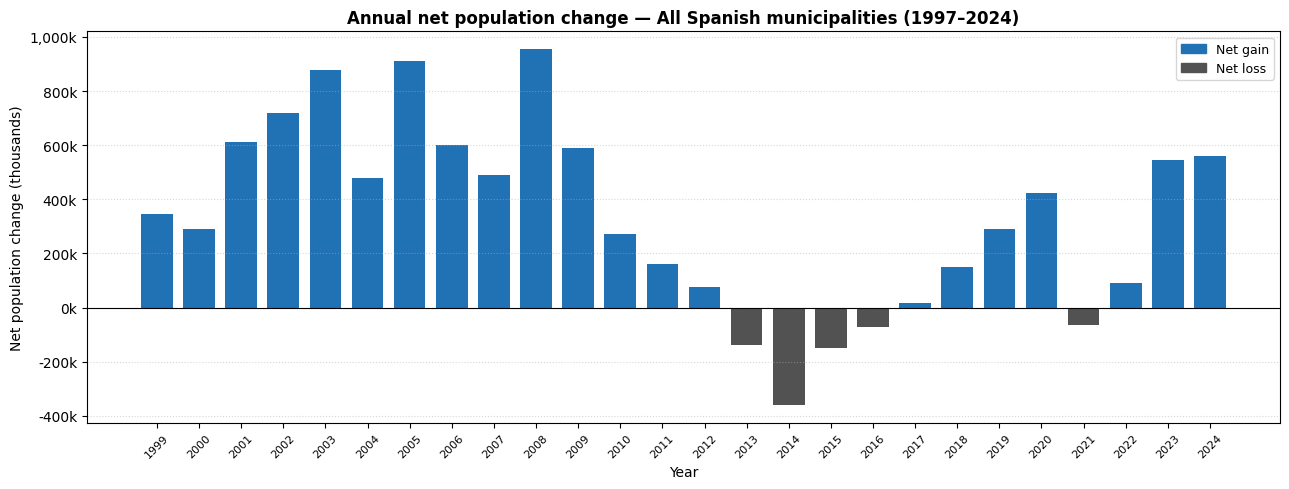

Saved → p1_fig1_national_net_change_en.png


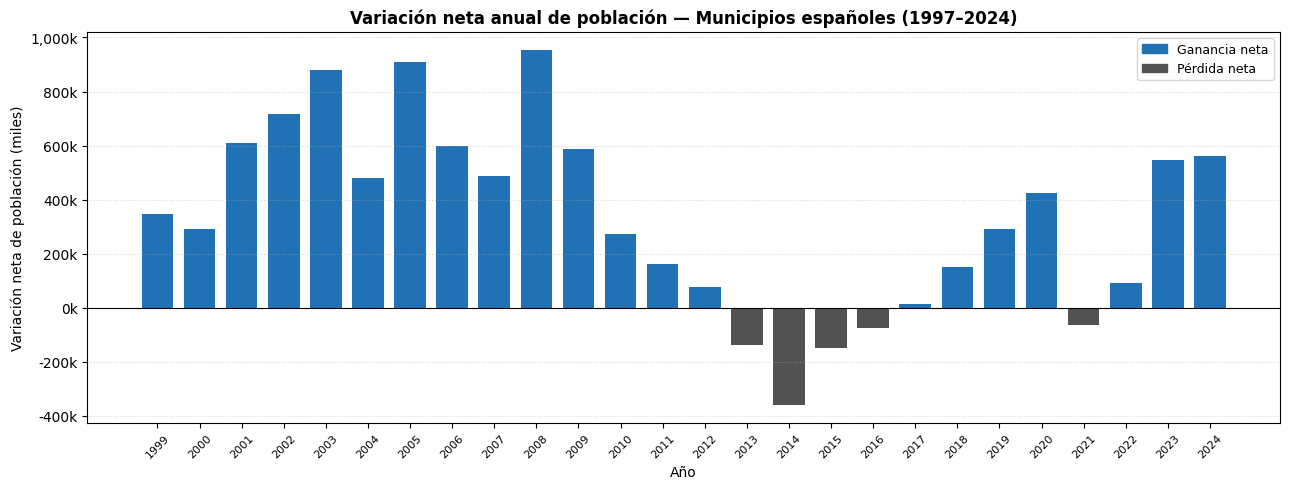

Saved → p1_fig1_national_net_change_es.png


In [12]:
# --- Figure 1 · National aggregate -----------------------------------
COL_NEG = "#525252"  # dark grey for net loss

for lang, labels in {
    "en": {
        "ylabel" : "Net population change (thousands)",
        "xlabel" : "Year",
        "title"  : "Annual net population change — All Spanish municipalities (1997–2024)",
        "gain"   : "Net gain",
        "loss"   : "Net loss",
    },
    "es": {
        "ylabel" : "Variación neta de población (miles)",
        "xlabel" : "Año",
        "title"  : "Variación neta anual de población — Municipios españoles (1997–2024)",
        "gain"   : "Ganancia neta",
        "loss"   : "Pérdida neta",
    },
}.items():

    # Explicitly redefine inside the loop
    years  = national["Year"].tolist()
    values = national["Net_change"].values

    fig, ax = plt.subplots(figsize=(13, 5))

    bar_colors = [COL_POS if v >= 0 else COL_NEG for v in values]
    ax.bar(years, values / 1000, color=bar_colors, edgecolor="none", width=0.75)
    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_ylabel(labels["ylabel"], fontsize=10)
    ax.set_xlabel(labels["xlabel"], fontsize=10)
    ax.set_title(labels["title"], fontsize=12, fontweight="bold")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}k"))
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.legend(handles=[
        mpatches.Patch(color=COL_POS, label=labels["gain"]),
        mpatches.Patch(color=COL_NEG, label=labels["loss"]),
    ], fontsize=9)

    plt.tight_layout()
    fp = FIGURES_DIR / f"p1_fig1_national_net_change_{lang}.png"
    plt.savefig(fp, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fp.name}")

---
## 5 · Figure 2 — By municipality size group (1997–2024)

Small multiples (3×2 grid). Each panel shows one size group.
The **< 5,000 (total)** panel aggregates the two smallest groups
for direct comparability with MITERD (2022).

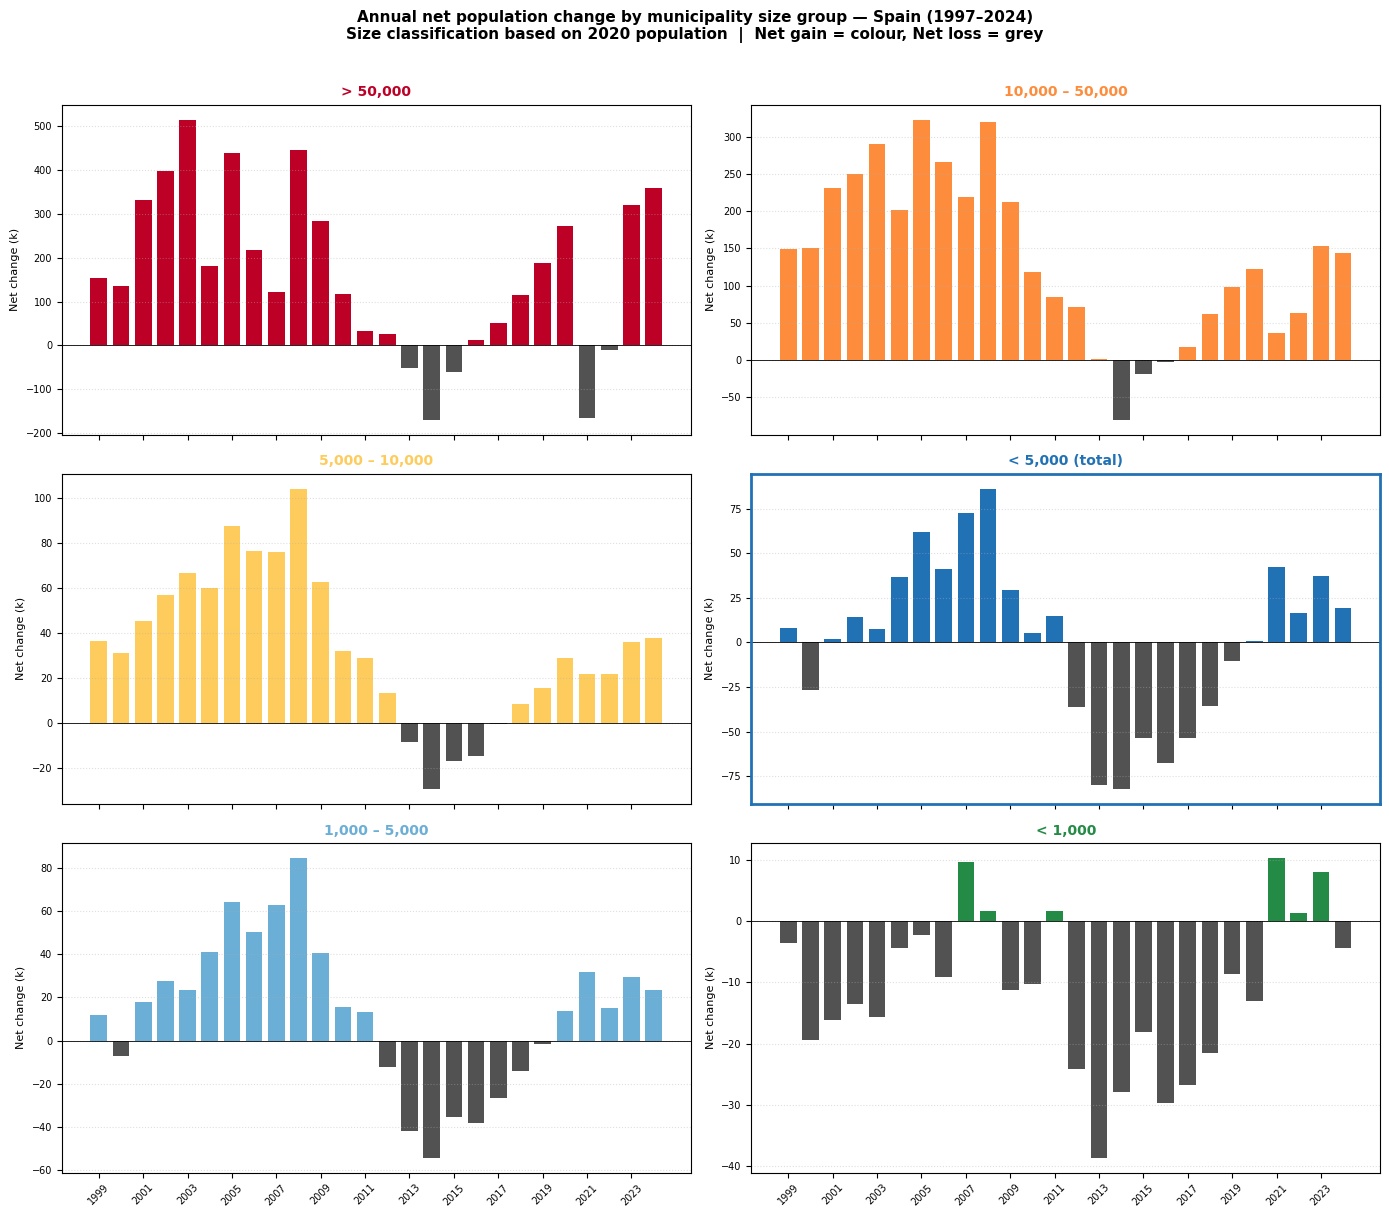

Saved → p1_fig2_size_combined_en.png
Saved → p1_fig2_size_pair_top_en.png
Saved → p1_fig2_size_pair_mid_en.png
Saved → p1_fig2_size_pair_bot_en.png
Saved → p1_fig2_size_individual_gt_50000_en.png
Saved → p1_fig2_size_individual_10000_–_50000_en.png
Saved → p1_fig2_size_individual_5000_–_10000_en.png
Saved → p1_fig2_size_individual_lt_5000_(total)_en.png
Saved → p1_fig2_size_individual_1000_–_5000_en.png
Saved → p1_fig2_size_individual_lt_1000_en.png
Saved → p1_fig2_size_combined_es.png
Saved → p1_fig2_size_pair_top_es.png
Saved → p1_fig2_size_pair_mid_es.png
Saved → p1_fig2_size_pair_bot_es.png
Saved → p1_fig2_size_individual_gt_50000_es.png
Saved → p1_fig2_size_individual_10000_–_50000_es.png
Saved → p1_fig2_size_individual_5000_–_10000_es.png
Saved → p1_fig2_size_individual_lt_5000_(total)_es.png
Saved → p1_fig2_size_individual_1000_–_5000_es.png
Saved → p1_fig2_size_individual_lt_1000_es.png

All Figure 2 variants saved.


In [13]:
# --- Figure 2 · By size group — all versions -------------------------
# Produces: combined (3x2), pairs (top/middle/bottom), and individual panels
# Two languages: English and Spanish

SIZE_LABELS = {
    "en": {
        "ylabel"   : "Net change (k)",
        "gain"     : "Net gain",
        "loss"     : "Net loss",
        "col_word" : "colour",
        "grey_word": "grey",
        "ref_note" : "Size classification based on 2020 population",
        "suptitle" : "Annual net population change by municipality size group — Spain (1997–2024)",
    },
    "es": {
        "ylabel"   : "Variación neta (miles)",
        "gain"     : "Ganancia neta",
        "loss"     : "Pérdida neta",
        "col_word" : "color",
        "grey_word": "gris",
        "ref_note" : "Clasificación por tamaño basada en población de 2020",
        "suptitle" : "Variación neta anual de población por grupo de tamaño — España (1997–2024)",
    },
}

SIZE_TITLES_ES = {
    "> 50,000"        : "> 50.000",
    "10,000 – 50,000" : "10.000 – 50.000",
    "5,000 – 10,000"  : "5.000 – 10.000",
    "< 5,000 (total)" : "< 5.000 (total)",
    "1,000 – 5,000"   : "1.000 – 5.000",
    "< 1,000"         : "< 1.000",
}

def draw_size_panel(ax, grp, lang, labels):
    sub    = by_size_full[by_size_full["size_group"] == grp].sort_values("Year")
    if sub.empty:
        ax.set_visible(False)
        return
    years  = sub["Year"].tolist()
    values = sub["Net_change"].values
    color  = SIZE_COLORS[grp]
    bar_colors = [color if v >= 0 else COL_NEG for v in values]
    ax.bar(years, values / 1000, color=bar_colors, edgecolor="none", width=0.75)
    ax.axhline(0, color="black", linewidth=0.6)
    if grp == "< 5,000 (total)":
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor(color)
    panel_title = SIZE_TITLES_ES[grp] if lang == "es" else grp
    ax.set_title(panel_title, fontsize=10, fontweight="bold", color=color)
    ax.set_ylabel(labels["ylabel"], fontsize=8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xticks(years[::2])
    ax.set_xticklabels(years[::2], rotation=45, fontsize=7)


for lang, labels in SIZE_LABELS.items():

    col_word  = labels["col_word"]
    grey_word = labels["grey_word"]
    subtitle  = (f"{labels['ref_note']}  |  "
                 f"{labels['gain']} = {col_word}, {labels['loss']} = {grey_word}")
    show_combined = (lang == "en")   # only display combined EN in notebook

    # ---- A) Combined 3x2 --------------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
    for i, grp in enumerate(SIZE_ORDER):
        draw_size_panel(axes.flatten()[i], grp, lang, labels)
    fig.suptitle(f"{labels['suptitle']}\n{subtitle}",
                 fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    fp = FIGURES_DIR / f"p1_fig2_size_combined_{lang}.png"
    plt.savefig(fp, dpi=300, bbox_inches="tight")
    if show_combined:
        plt.show()
    else:
        plt.close()
    print(f"Saved → {fp.name}")

    # ---- B) Pairs (top, middle, bottom) -----------------------------
    for pair_idx, pair_name in enumerate(["top", "mid", "bot"]):
        grp_a = SIZE_ORDER[pair_idx * 2]
        grp_b = SIZE_ORDER[pair_idx * 2 + 1]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
        draw_size_panel(axes[0], grp_a, lang, labels)
        draw_size_panel(axes[1], grp_b, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{subtitle}",
                     fontsize=11, fontweight="bold", y=1.02)
        plt.tight_layout()
        fp = FIGURES_DIR / f"p1_fig2_size_pair_{pair_name}_{lang}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved → {fp.name}")

    # ---- C) Individual panels ---------------------------------------
    for grp in SIZE_ORDER:
        fig, ax = plt.subplots(figsize=(8, 5))
        draw_size_panel(ax, grp, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{subtitle}",
                     fontsize=10, fontweight="bold", y=1.02)
        plt.tight_layout()
        slug = grp.replace(",", "").replace(" ", "_").replace(">", "gt").replace("<", "lt")
        fp = FIGURES_DIR / f"p1_fig2_size_individual_{slug}_{lang}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved → {fp.name}")

print("\nAll Figure 2 variants saved.")

---
## 6 · Figure 3 — By Goerlich (2016) typology (1997–2024)

Same layout as Figure 2 but stratified by functional typology.
Ordered from most urban to most rural.

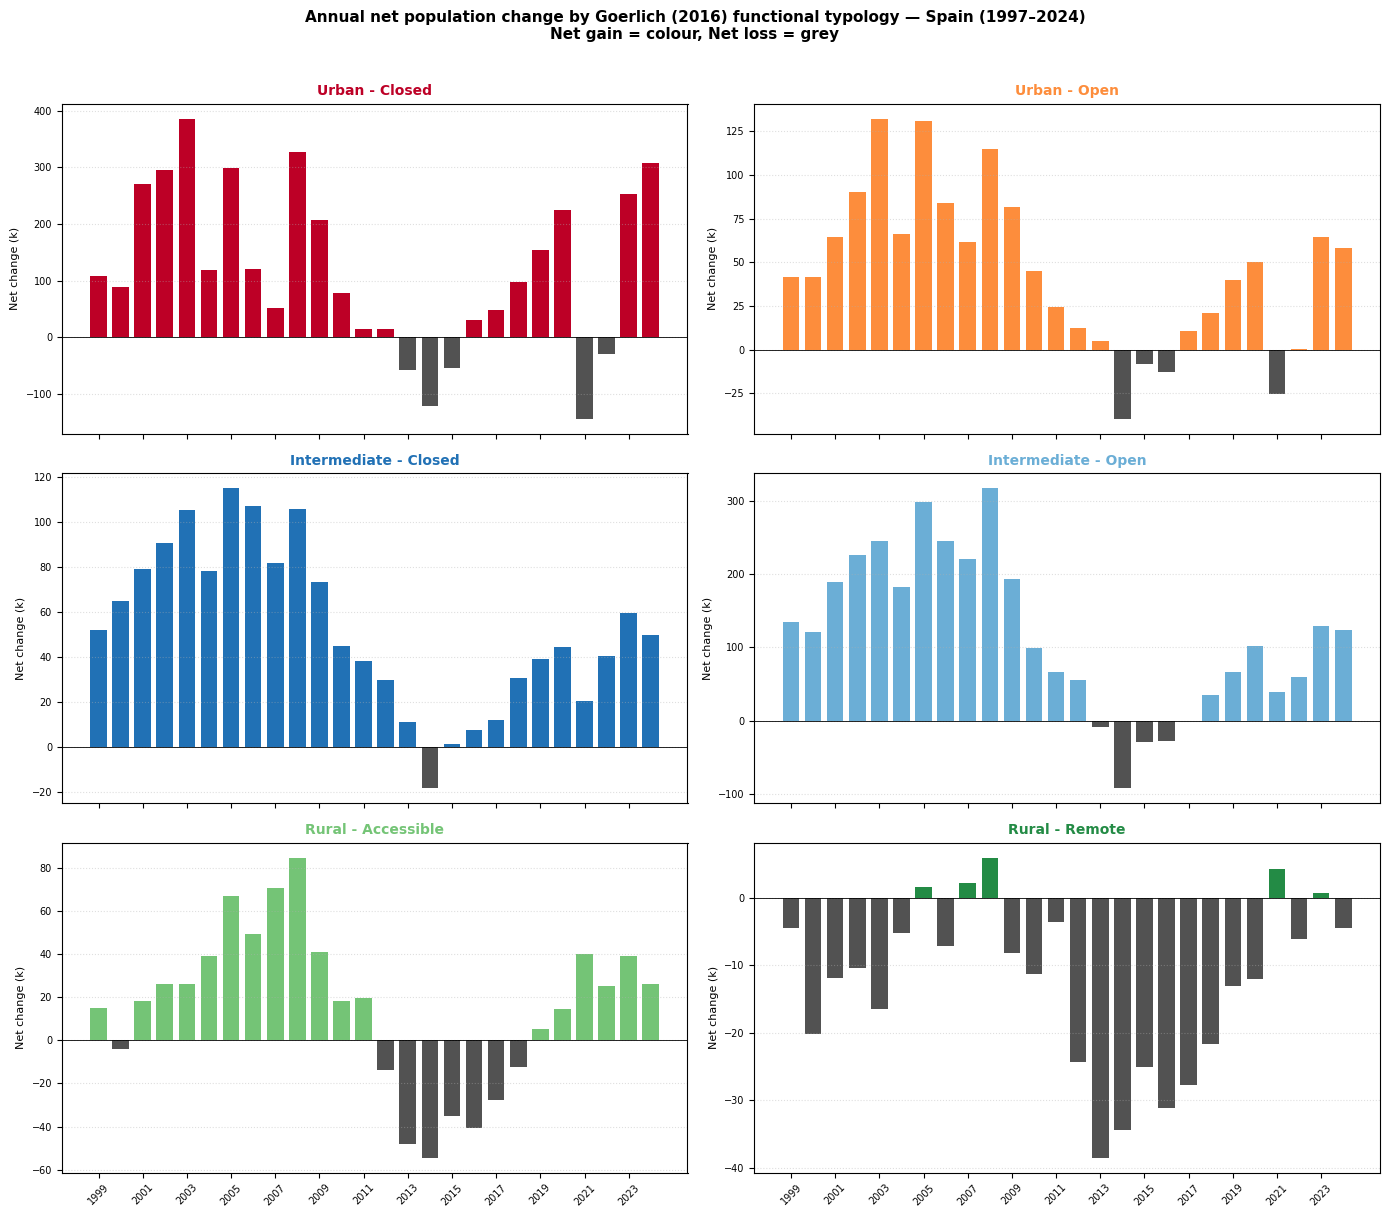

Saved → p1_fig3_typology_combined_en.png
Saved → p1_fig3_typology_pair_top_en.png
Saved → p1_fig3_typology_pair_mid_en.png
Saved → p1_fig3_typology_pair_bot_en.png
Saved → p1_fig3_typology_individual_Urbano_Cerrado_en.png
Saved → p1_fig3_typology_individual_Urbano_Abierto_en.png
Saved → p1_fig3_typology_individual_Intermedio_Cerrado_en.png
Saved → p1_fig3_typology_individual_Intermedio_Abierto_en.png
Saved → p1_fig3_typology_individual_Rural_Accesible_en.png
Saved → p1_fig3_typology_individual_Rural_Remoto_en.png
Saved → p1_fig3_typology_combined_es.png
Saved → p1_fig3_typology_pair_top_es.png
Saved → p1_fig3_typology_pair_mid_es.png
Saved → p1_fig3_typology_pair_bot_es.png
Saved → p1_fig3_typology_individual_Urbano_Cerrado_es.png
Saved → p1_fig3_typology_individual_Urbano_Abierto_es.png
Saved → p1_fig3_typology_individual_Intermedio_Cerrado_es.png
Saved → p1_fig3_typology_individual_Intermedio_Abierto_es.png
Saved → p1_fig3_typology_individual_Rural_Accesible_es.png
Saved → p1_fig3_ty

In [14]:
# --- Figure 3 · By Goerlich typology — all versions ------------------
# Produces: combined (3x2), pairs (top/middle/bottom), and individual panels
# Two languages: English and Spanish

TYPOLOGY_LABELS = {
    "en": {
        "ylabel"   : "Net change (k)",
        "gain"     : "Net gain",
        "loss"     : "Net loss",
        "col_word" : "colour",
        "grey_word": "grey",
        "suptitle" : "Annual net population change by Goerlich (2016) functional typology — Spain (1997–2024)",
    },
    "es": {
        "ylabel"   : "Variación neta (miles)",
        "gain"     : "Ganancia neta",
        "loss"     : "Pérdida neta",
        "col_word" : "color",
        "grey_word": "gris",
        "suptitle" : "Variación neta anual de población por tipología funcional Goerlich (2016) — España (1997–2024)",
    },
}

TYPOLOGY_TITLES_ES = {
    "Urbano - Cerrado"     : "Urbano - Cerrado",
    "Urbano - Abierto"     : "Urbano - Abierto",
    "Intermedio - Cerrado" : "Intermedio - Cerrado",
    "Intermedio - Abierto" : "Intermedio - Abierto",
    "Rural - Accesible"    : "Rural - Accesible",
    "Rural - Remoto"       : "Rural - Remoto",
}

TYPOLOGY_TITLES_EN = {
    "Urbano - Cerrado"     : "Urban - Closed",
    "Urbano - Abierto"     : "Urban - Open",
    "Intermedio - Cerrado" : "Intermediate - Closed",
    "Intermedio - Abierto" : "Intermediate - Open",
    "Rural - Accesible"    : "Rural - Accessible",
    "Rural - Remoto"       : "Rural - Remote",
}

def draw_typology_panel(ax, typ, lang, labels):
    sub    = by_typology[by_typology["tipo_goerlich"] == typ].sort_values("Year")
    if sub.empty:
        ax.set_visible(False)
        return
    years  = sub["Year"].tolist()
    values = sub["Net_change"].values
    color  = GOERLICH_COLORS[typ]
    bar_colors = [color if v >= 0 else COL_NEG for v in values]
    ax.bar(years, values / 1000, color=bar_colors, edgecolor="none", width=0.75)
    ax.axhline(0, color="black", linewidth=0.6)
    panel_title = TYPOLOGY_TITLES_EN[typ] if lang == "en" else TYPOLOGY_TITLES_ES[typ]
    ax.set_title(panel_title, fontsize=10, fontweight="bold", color=color)
    ax.set_ylabel(labels["ylabel"], fontsize=8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xticks(years[::2])
    ax.set_xticklabels(years[::2], rotation=45, fontsize=7)


for lang, labels in TYPOLOGY_LABELS.items():

    col_word  = labels["col_word"]
    grey_word = labels["grey_word"]
    subtitle  = f"{labels['gain']} = {col_word}, {labels['loss']} = {grey_word}"
    show_combined = (lang == "en")

    # ---- A) Combined 3x2 --------------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
    for i, typ in enumerate(TYPOLOGY_ORDER):
        draw_typology_panel(axes.flatten()[i], typ, lang, labels)
    fig.suptitle(f"{labels['suptitle']}\n{subtitle}",
                 fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    fp = FIGURES_DIR / f"p1_fig3_typology_combined_{lang}.png"
    plt.savefig(fp, dpi=300, bbox_inches="tight")
    if show_combined:
        plt.show()
    else:
        plt.close()
    print(f"Saved → {fp.name}")

    # ---- B) Pairs (top, middle, bottom) -----------------------------
    for pair_idx, pair_name in enumerate(["top", "mid", "bot"]):
        typ_a = TYPOLOGY_ORDER[pair_idx * 2]
        typ_b = TYPOLOGY_ORDER[pair_idx * 2 + 1]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
        draw_typology_panel(axes[0], typ_a, lang, labels)
        draw_typology_panel(axes[1], typ_b, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{subtitle}",
                     fontsize=11, fontweight="bold", y=1.02)
        plt.tight_layout()
        fp = FIGURES_DIR / f"p1_fig3_typology_pair_{pair_name}_{lang}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved → {fp.name}")

    # ---- C) Individual panels ---------------------------------------
    for typ in TYPOLOGY_ORDER:
        fig, ax = plt.subplots(figsize=(8, 5))
        draw_typology_panel(ax, typ, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{subtitle}",
                     fontsize=10, fontweight="bold", y=1.02)
        plt.tight_layout()
        slug = typ.replace(" ", "_").replace("-", "").replace("__", "_")
        fp = FIGURES_DIR / f"p1_fig3_typology_individual_{slug}_{lang}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved → {fp.name}")

print("\nAll Figure 3 variants saved.")

---
## 7 · Interpretation notes


**Key findings from this notebook (p1a):**

- For **all Spanish municipalities**, net padrón change becomes positive from 2017,
  with a brief return to negative in 2021 (COVID excess mortality effect), and
  sustained recovery from 2022 onwards.
- For **municipalities < 5,000 hab.**, sustained recovery begins in **2020**,
  approximately two years after the 2018 inflection identified by MITERD (2022)
  using residential flow data (EVR). This lag is consistent with the structural
  negative vegetative balance of small rural municipalities, where deaths
  systematically outnumber births — the migratory recovery is real but partially
  masked by vegetative losses until ~2020.
- The earlier positive period (1999–2009) reflects the immigration boom of the
  early 2000s and is analytically distinct from the post-2018 neo-rural phenomenon
  that is the focus of this paper. The analysis focuses on the **post-2015 period**
  as the relevant window for recent counter-urbanization dynamics, consistent with
  Herrero-Jáuregui & Concepción (2023).

**Key questions to address jointly with p1b:**

1. Does removing the vegetative balance (p1b) bring the inflection year closer to 2018?
2. Do smaller municipalities (< 1,000 hab.) show a later recovery than larger rural ones?
3. Does Rural Remoto show a different trajectory than Rural Accesible?
4. Do urban typologies show an earlier population loss, consistent with an urban-to-rural shift?
5. Is the 2020 peak an anomaly (COVID effect) or the consolidation of a sustained trend?

---
## 8 · Dependencies

All packages are standard and available in the `rural-migration` conda environment:
```
pandas, numpy, matplotlib
```

No additional installs required for this notebook.